<a href="https://colab.research.google.com/github/aswathimv/module2_end_assignment/blob/main/Module2_End_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [37]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [38]:
df=pd.read_csv('/content/ABC Company.xlsx - Sheet1.csv')
df

,Name,Team,Number,Position,Age,Height,Weight,College,Salary
0,Avery Bradley,Boston Celtics,0,PG,25,06-Feb,180,Texas,7730337.0
1,Jae Crowder,Boston Celtics,99,SF,25,06-Jun,235,Marquette,6796117.0
2,John Holland,Boston Celtics,30,SG,27,06-May,205,Boston University,NaN
3,R.J. Hunter,Boston Celtics,28,SG,22,06-May,185,Georgia State,1148640.0
4,Jonas Jerebko,Boston Celtics,8,PF,29,06-Oct,231,NaN,5000000.0
...,...,...,...,...,...,...,...,...,...
453,Shelvin Mack,Utah Jazz,8,PG,26,06-Mar,203,Butler,2433333.0
454,Raul Neto,Utah Jazz,25,PG,24,06-Jan,179,NaN,900000.0
455,Tibor Pleiss,Utah Jazz,21,C,26,07-Mar,256,NaN,2900000.0
456,Jeff Withey,Utah Jazz,24,C,26,7-0,231,Kansas,947276.0


In [39]:
#Preprocessing:
#● Correct the data in the "height" column by replacing it with random
#numbers between 150 and 180. Ensure data consistency and integrity
#before proceeding with analysis. (1 mark)

np.random.seed(0)
df['Height']=np.random.randint(150,180,len(df))
df


,Name,Team,Number,Position,Age,Height,Weight,College,Salary
0,Avery Bradley,Boston Celtics,0,PG,25,162,180,Texas,7730337.0
1,Jae Crowder,Boston Celtics,99,SF,25,165,235,Marquette,6796117.0
2,John Holland,Boston Celtics,30,SG,27,171,205,Boston University,NaN
3,R.J. Hunter,Boston Celtics,28,SG,22,150,185,Georgia State,1148640.0
4,Jonas Jerebko,Boston Celtics,8,PF,29,153,231,NaN,5000000.0
...,...,...,...,...,...,...,...,...,...
453,Shelvin Mack,Utah Jazz,8,PG,26,157,203,Butler,2433333.0
454,Raul Neto,Utah Jazz,25,PG,24,178,179,NaN,900000.0
455,Tibor Pleiss,Utah Jazz,21,C,26,163,256,NaN,2900000.0
456,Jeff Withey,Utah Jazz,24,C,26,176,231,Kansas,947276.0


In [40]:
#Analysis Tasks:
#● Determine the distribution of employees across each team and calculate
#the percentage split relative to the total number of employees. (2 marks)
team_no=df['Team'].value_counts()
#percentage=(team_no/len(df))*100

count_percent=df['Team'].value_counts(normalize=True)*100 #here normalize=true is a function inside value_counts()
#  to divide the count of members by len of dataset then we multiply by 100 to get the percentage
print("TEAM COUNT\n",team_no)
print("\n\nPERCENTAGE\n",count_percent)

TEAM COUNT
 Team
New Orleans Pelicans      19
Memphis Grizzlies         18
Utah Jazz                 16
Milwaukee Bucks           16
New York Knicks           16
Boston Celtics            15
Los Angeles Clippers      15
Los Angeles Lakers        15
Phoenix Suns              15
Sacramento Kings          15
Brooklyn Nets             15
Philadelphia 76ers        15
Toronto Raptors           15
Golden State Warriors     15
Indiana Pacers            15
Detroit Pistons           15
Cleveland Cavaliers       15
Chicago Bulls             15
Houston Rockets           15
San Antonio Spurs         15
Atlanta Hawks             15
Dallas Mavericks          15
Charlotte Hornets         15
Miami Heat                15
Denver Nuggets            15
Washington Wizards        15
Portland Trail Blazers    15
Oklahoma City Thunder     15
Orlando Magic             14
Minnesota Timberwolves    14
Name: count, dtype: int64


PERCENTAGE
 Team
New Orleans Pelicans      4.148472
Memphis Grizzlies         3.93013

In [41]:
#● Segregate employees based on their positions within the company. (2marks)
position_count=df['Position'].value_counts()
position_count

,count
Position,
SG,102
PF,100
PG,92
SF,85
C,79


In [42]:
#● Identify the predominant age group among employees. (2 marks)

bins = [18,21,24,27,30,33,36,39,42,45]  # this sets the range values for age group that pd.cut() creates
df["Age_range"]=pd.cut(df['Age'],bins=bins)
age_group=df["Age_range"].value_counts().sort_index()
print(age_group)
print("\n\nAge group ",age_group.idxmax()," has maximum employees.")

Age_range
(18, 21]     40
(21, 24]    114
(24, 27]    123
(27, 30]     90
(30, 33]     49
(33, 36]     29
(36, 39]     10
(39, 42]      3
(42, 45]      0
Name: count, dtype: int64


Age group  (24, 27]  has maximum employees.


In [43]:
#● Discover which team and position have the highest salary expenditure. (2marks)

#salary expenditure means total sum of salary given to the whole team ort position

print("Team with highest salary expenditure",df.groupby("Team")["Salary"].sum().sort_values(ascending=False).head(1))
print("\n\nPosition with highest salary expenditure",df.groupby("Position")["Salary"].sum().sort_values(ascending=False).head(1))


Team with highest salary expenditure Team
Cleveland Cavaliers    106988689.0
Name: Salary, dtype: float64


Position with highest salary expenditure Position
C    466377332.0
Name: Salary, dtype: float64


             Age    Salary
Age     1.000000  0.214009
Salary  0.214009  1.000000


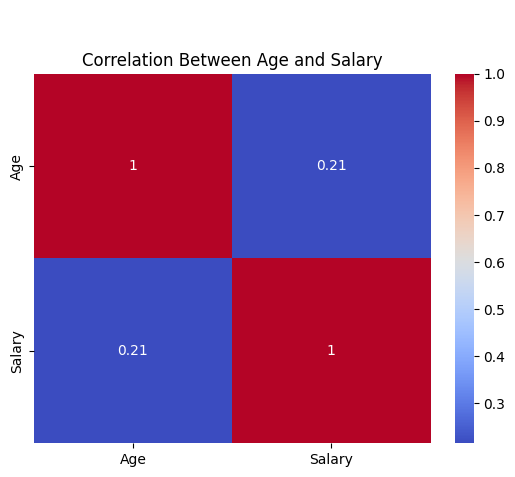

In [44]:
#● Investigate if there's any correlation between age and salary, and represent it visually. (2 marks)

print(df[["Age","Salary"]].corr())

sns.heatmap(df[["Age", "Salary"]].corr(), annot=True, cmap="coolwarm")
plt.title("\n\nCorrelation Between Age and Salary")
plt.show()

#this plotting indicates a positive value indicating as age increases salary increases but still the valuye is near to 0,so it a weak correlation.

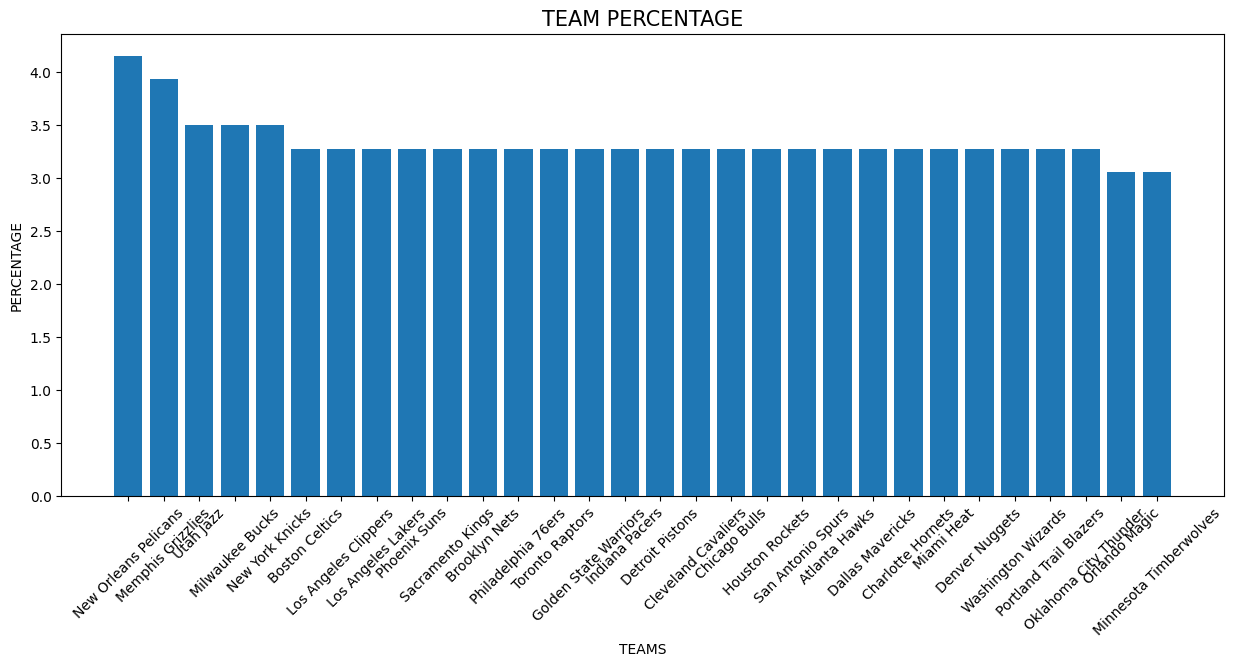

In [45]:
#● For each of the five analysis tasks above, create appropriate visualizations
#to present your findings effectively.


# 1) BAR GRAPH
plt.figure(figsize=(15,6))
team=count_percent.index
percentage=count_percent.values
#plt.bar(sub,marks,color="green")
plt.bar(team,percentage)
plt.xlabel("TEAMS",color="black",size=10)
plt.ylabel("PERCENTAGE",color="black",size=10)
plt.title("TEAM PERCENTAGE",color="black",size=15)
plt.xticks(rotation=45)
plt.show()

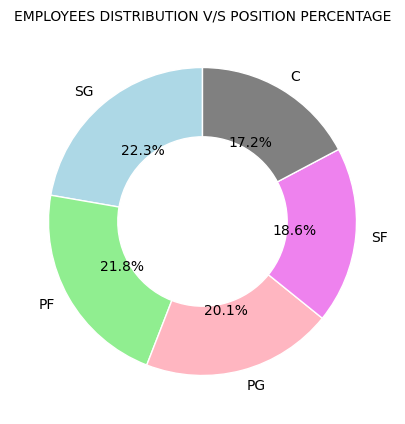

In [46]:
# 2) PIE CHART FOR POSITION COUNT
from matplotlib.patches import Shadow
plt.figure(figsize=(9,5))
colors=["lightblue","lightgreen","lightpink","violet","grey"]
positions=position_count.index
position_no=position_count.values
plt.pie(position_no,labels=positions,colors=colors,autopct="%1.1f%%", wedgeprops={"width":0.45, "edgecolor":"white"},startangle=90)
plt.title("EMPLOYEES DISTRIBUTION V/S POSITION PERCENTAGE",color="black",size=10)
#plt.legend(loc="lower left",shadow=True)
plt.show()

#here in this plotting we use pie chart which precisely and easily dictates the percentage of employees in each position in the
#company

Text(0.5, 1.0, 'AGE GROUP V/S COUNT PLOT')

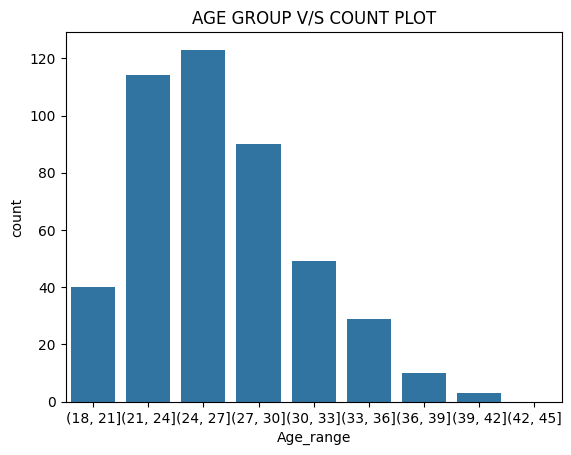

In [47]:
# 3) COUNT PLOT used to show how many we have in each category/group.

sns.countplot(data=df, x=df['Age_range'])
plt.title("AGE GROUP V/S COUNT PLOT")


#so for plotting the age group we use countplot,so its eaasy to see which age group has more number of employees.


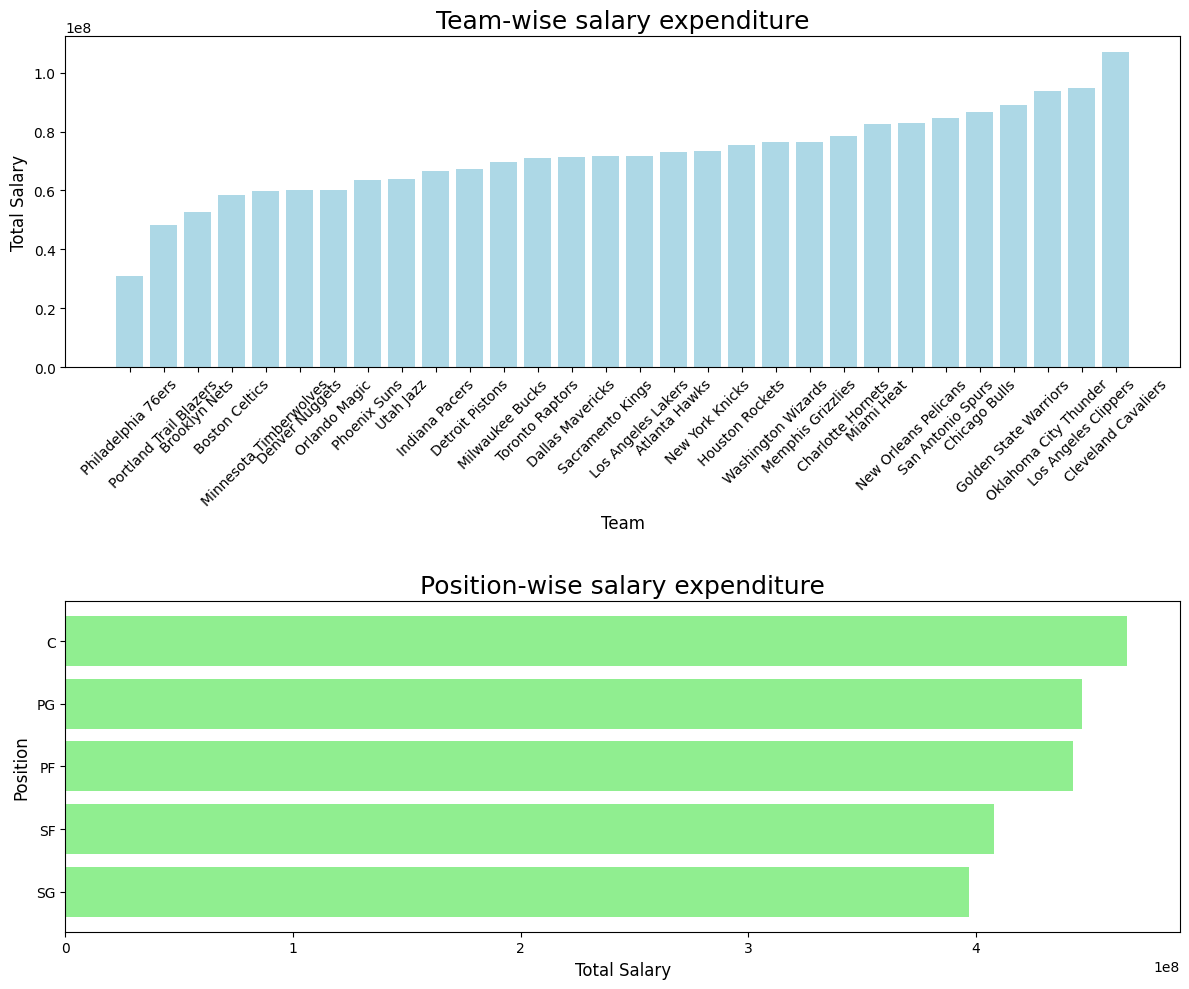

'\nhere we use bar chart for better understandability of data ,we use both normal bar plot and horizontal bar plot here.\nthe barchart cleary shows the total salary for each team  and also position easily .Since the graph is plotted as "le8" the \ntotal salary amt is depicted like this\n'

In [48]:
# 5) BAR CHART

salary_count=df.groupby("Team")["Salary"].sum().sort_values()
position_count=df.groupby("Position")["Salary"].sum().sort_values()

fig,ax=plt.subplots(2,1,figsize=(12,10))
ax[0].bar(salary_count.index,salary_count.values,color="lightblue")
ax[0].set_title("Team-wise salary expenditure",fontsize=18)
ax[0].set_xlabel("Team",fontsize=12)
ax[0].set_ylabel("Total Salary",fontsize=12)
ax[0].tick_params(axis='x', rotation=45)
ax[1].barh(position_count.index,position_count.values,color="lightgreen")
ax[1].set_title("Position-wise salary expenditure",fontsize=18)
ax[1].set_ylabel("Position",fontsize=12)
ax[1].set_xlabel("Total Salary",fontsize=12)
plt.tight_layout(h_pad=3)
plt.show()

'''
here we use bar chart for better understandability of data ,we use both normal bar plot and horizontal bar plot here.
the barchart cleary shows the total salary for each team  and also position easily .Since the graph is plotted as "le8" the
total salary amt is depicted like this
'''

'\nhere this graph shows us that as age increases the salary increases but theres no big of an increase,even though the correlation \nis postive its a weak correlation.\n'

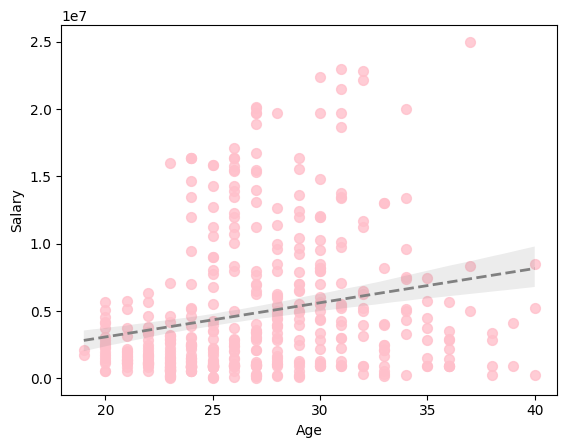

In [49]:
# here for plotting we use scatter plot with regression line for better understandability,we can use scatter plot or heat map to
# find the correlation since we have used the heat map above ,here we use scatterplot.

sns.regplot(x="Age",y="Salary",data=df,scatter_kws={"s":50,"color":"pink"},
    line_kws={"color":"grey", "linewidth":2,"linestyle":"dashed"})


'''
here this graph shows us that as age increases the salary increases but theres no big of an increase,even though the correlation
is postive its a weak correlation.
'''


In [50]:
#DATA STORY

'''
1)TEAM DISTRIBUTION
      The first analysis and graph tells us about how the workforce/employees is being distributed amoung different teams.
We cqan see that some teams have more no of employees assigned while others have a few less,this indicated the uneven
allocation of employees based on workload in different teams.

2)POSITION DISTRIBUTION
      Here we can see that there are only a few /handful of positions when compared to the teams,and majority of the employees
  concentrated to a few main positions,this indicates that these positions/roles plays a major role in the workforce.

3)AGE GROUP
      In this case we group the age 10  bins for analysing easily to get an overview of in which age group we have the majority
  of employees,hence we were able to pinpoint that most of the employees fall under [24-27] and [21,24] age group ,showing that
  the company have more youth workforce.

4)SALARY EXPENDITURE
      Here in this analysis and the graph we plotted shows how much salary they are being given as a whole for the team or position,
  in our casr we can see that the team "Cleveland Cavaliers" has the highest salary expenditure where as when we look into
  position wise we have position "C" with highest salary expenditure.

5)Age vs Salary
      Here we are analysis whether there is any correlation between age and salary,while analyzing we can see that the
  correlation is 0.214 which indicates a positive correlatoin which indicates that there is slight salary increase with age.
  Even though the relation is positive but its a smaller value and near to zero hence the relationship is not strong.
'''

'\n1)TEAM DISTRIBUTION\n      The first analysis and graph tells us about how the workforce/employees is being distributed amoung different teams.\nWe cqan see that some teams have more no of employees assigned while others have a few less,this indicated the uneven \nallocation of employees based on workload in different teams.\n\n2)POSITION DISTRIBUTION\n      Here we can see that there are only a few /handful of positions when compared to the teams,and majority of the employees \n  concentrated to a few main positions,this indicates that these positions/roles plays a major role in the workforce.\n\n3)AGE GROUP\n      In this case we group the age 10  bins for analysing easily to get an overview of in which age group we have the majority \n  of employees,hence we were able to pinpoint that most of the employees fall under [24-27] and [21,24] age group ,showing that\n  the company have more youth workforce.\n\n4)SALARY EXPENDITURE\n      Here in this analysis and the graph we plotted s